# Customer Segmentation using K-Means Clustering Algorithm 

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data collection using kaggle dataset Mall customers

# data input module

In [114]:
df=pd.read_csv('Mall_Customers.csv')

In [115]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [116]:
df.shape

(200, 5)

# data preprocessing
# data preprocessing module

In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


# feature extraction 

In [118]:
#Creating a seperate dataframe X
X=df.iloc[:,[3,4]].values 
#retrieve data
#iloc used to extract data based on columns
X #The 3rd and 4th columns r shown

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

# Performing elbow method to find the optimal number of customers


# using K-Means to iterate from 1 to 11 clusters plotting a Elbow plot and deciding the optimal number of clusters to be used

# cluster module

In [119]:
from sklearn.cluster import KMeans
wcss=[]  #Vwithin clusters sum of squares for k
#this is distance between each poimt and the centroid in a cluster

In [120]:
# as no of clusters increase the wcss value decrease
#wcss value is largest when k=1

In [121]:
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

#kmeans.inertia is used to segregate the data points into clusters

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

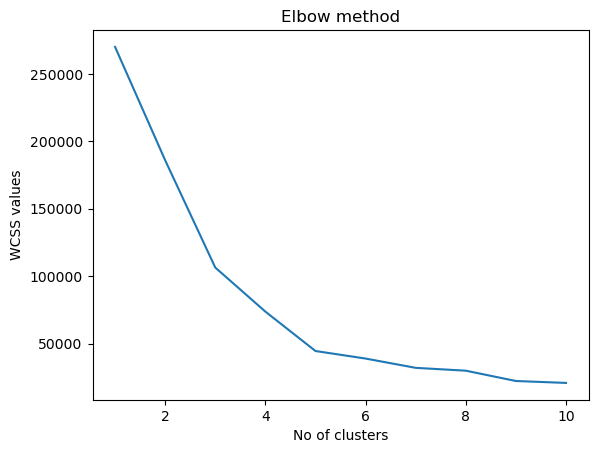

In [122]:
plt.plot(range(1,11),wcss)
plt.title('Elbow method')
plt.xlabel('No of clusters')
plt.ylabel('WCSS values')
plt.show()

# we are getting elbow at k=5
# so number of optimal clusters=5

# Initialise our KMeans model with selected optimal number of clusters(k=5)

In [123]:
kmeansmodel = KMeans(n_clusters=5, init='k-means++', random_state=42)

# Model prediction

In [124]:
y_kmeans = kmeansmodel.fit_predict(X)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


# visualization
# visualization module

Text(0, 0.5, 'Spending score')

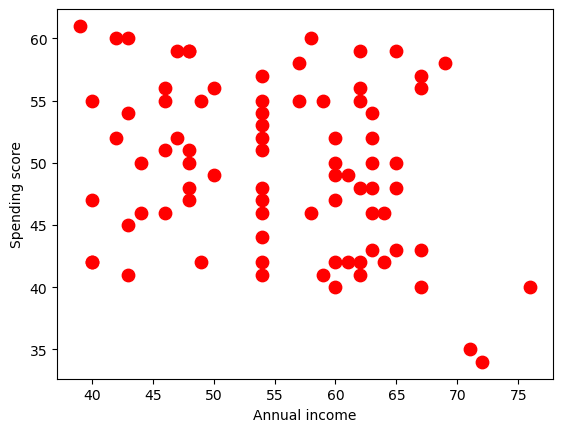

In [125]:
plt.scatter(X[y_kmeans==0,0],X[y_kmeans==0,1],s=80,c="red",label='Customer1')
plt.xlabel("Annual income")
plt.ylabel("Spending score")

Text(0, 0.5, 'Spending score')

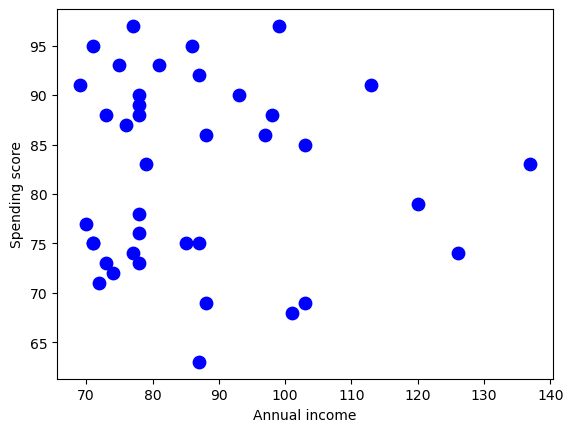

In [126]:
plt.scatter(X[y_kmeans==1,0],X[y_kmeans==1,1],s=80,c="blue",label='Customer2')
plt.xlabel("Annual income")
plt.ylabel("Spending score")

Text(0, 0.5, 'Spending score')

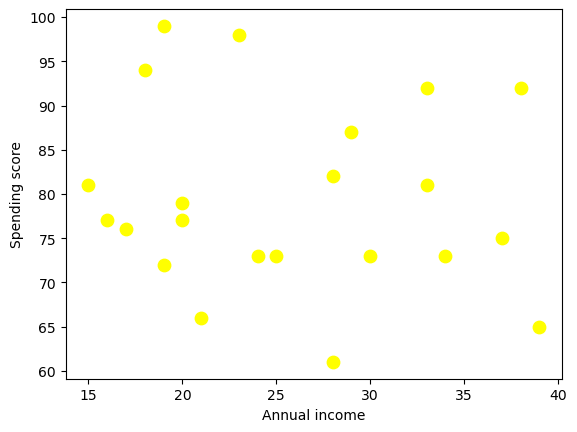

In [127]:
plt.scatter(X[y_kmeans==2,0],X[y_kmeans==2,1],s=80,c="yellow",label='Customer3')
plt.xlabel("Annual income")
plt.ylabel("Spending score")

Text(0, 0.5, 'Spending score')

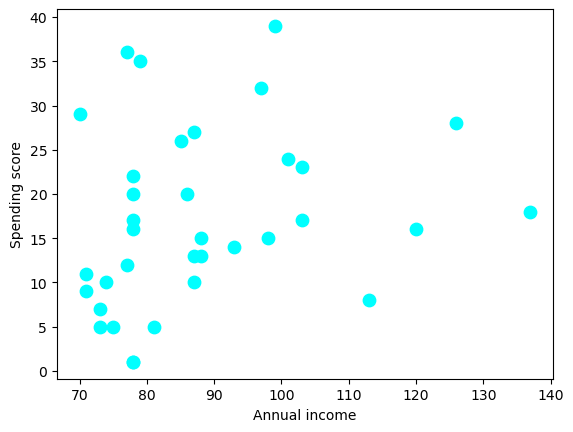

In [128]:
plt.scatter(X[y_kmeans==3,0],X[y_kmeans==3,1],s=80,c="cyan",label='Customer4')
plt.xlabel("Annual income")
plt.ylabel("Spending score")

Text(0, 0.5, 'Spending score')

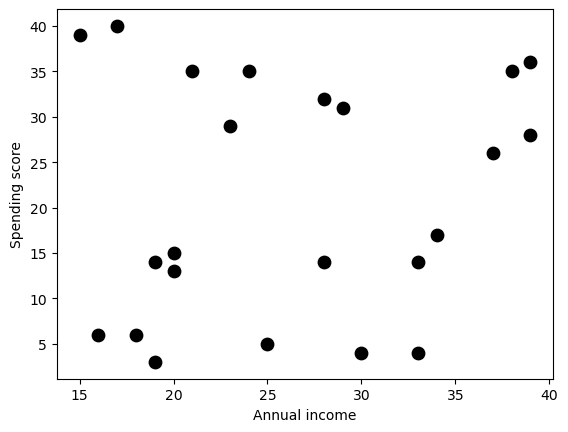

In [129]:
plt.scatter(X[y_kmeans==4,0],X[y_kmeans==4,1],s=80,c="black",label='Customer5')
plt.xlabel("Annual income")
plt.ylabel("Spending score")

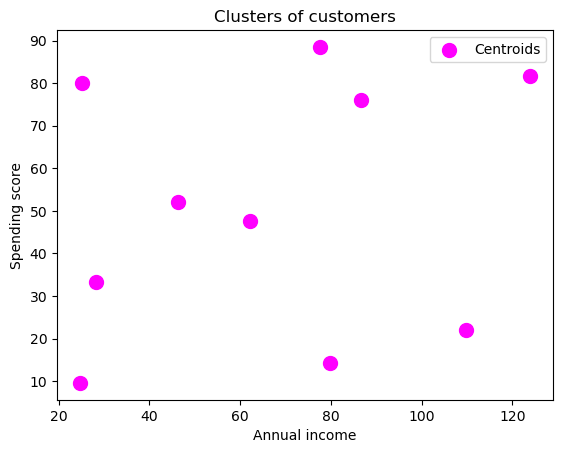

In [130]:
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s=100,c="magenta",label="Centroids")
plt.title("Clusters of customers")
plt.xlabel("Annual income")
plt.ylabel("Spending score")
plt.legend()
plt.show()

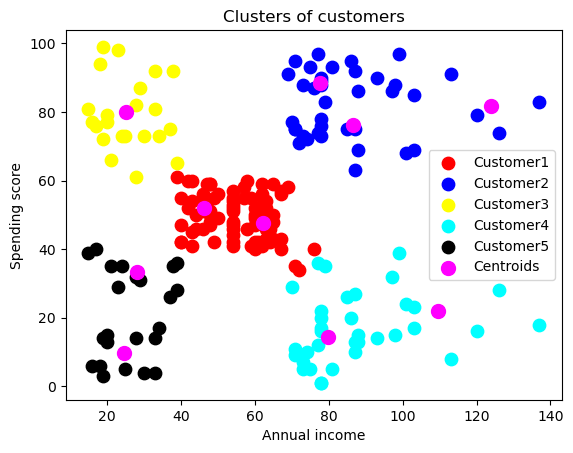

In [131]:
plt.scatter(X[y_kmeans==0,0],X[y_kmeans==0,1],s=80,c="red",label='Customer1')
plt.scatter(X[y_kmeans==1,0],X[y_kmeans==1,1],s=80,c="blue",label='Customer2')
plt.scatter(X[y_kmeans==2,0],X[y_kmeans==2,1],s=80,c="yellow",label='Customer3')
plt.scatter(X[y_kmeans==3,0],X[y_kmeans==3,1],s=80,c="cyan",label='Customer4')
plt.scatter(X[y_kmeans==4,0],X[y_kmeans==4,1],s=80,c="black",label='Customer5')
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s=100,c="magenta",label="Centroids")
plt.title("Clusters of customers")
plt.xlabel("Annual income")
plt.ylabel("Spending score")
plt.legend()
plt.show()

# analysis module

# evaluation

Top-Left Cluster: Represents customers with relatively lower annual income but a high spending score.
Black-colored Cluster: Represents customers with a high annual income but a lower spending score.
The third cluster stands out as the most valuable, as these individuals exhibit both decent income and a good spending score. 
Companies often prioritize this group to promote products effectively 

Specifically:
The business should reward Customer 2 (Blue) with loyalty programs to ensure retention.
The business should target Customer 4 (Cyan) with specific promotions or discounts to encourage them to spend more of their high income.
The business can minimize marketing costs on Customer 5 (Black) or offer them extreme budget-friendly deals.